In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')

# Style settings
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'figure.dpi': 120,
    'savefig.dpi': 150,
})

# Custom color palettes
TEAL_PALETTE = ['#0d1b2a', '#1b2838', '#0f4c5c', '#0b6477', '#14919b', '#00e676', '#ff6d00', '#e63946', '#ffd60a', '#ff4081']
ORGAN_COLORS = {'Kidney': '#00bfa5', 'Liver': '#ff6d00', 'Heart': '#ff1744', 'Lung': '#2979ff', 'Pancreas': '#ffd600', 'Intestine': '#00e676', 'Cornea': '#7c4dff', 'Bone Marrow / Stem Cells': '#e040fb'}
CONTINENT_COLORS = {'Europe': '#2979ff', 'Americas': '#ff6d00', 'Asia': '#ffd600', 'Oceania': '#00e676', 'Africa': '#ff1744'}

print("✅ All libraries loaded successfully!")
print("📊 Ready for analysis.")

✅ All libraries loaded successfully!
📊 Ready for analysis.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/organ-donation-and-transplant-dataset-2023-2024/organ_donation_by_country.csv
/kaggle/input/organ-donation-and-transplant-dataset-2023-2024/us_waiting_list.csv
/kaggle/input/organ-donation-and-transplant-dataset-2023-2024/organ_transplants_by_type.csv


In [3]:
# Load all datasets
df_country = pd.read_csv("/kaggle/input/organ-donation-and-transplant-dataset-2023-2024/organ_donation_by_country.csv")
df_organ = pd.read_csv("/kaggle/input/organ-donation-and-transplant-dataset-2023-2024/organ_transplants_by_type.csv")
df_waitlist = pd.read_csv("/kaggle/input/organ-donation-and-transplant-dataset-2023-2024/us_waiting_list.csv")

print(f"🌍 Country Dataset:  {df_country.shape[0]} countries × {df_country.shape[1]} features")
print(f"🫀 Organ Dataset:    {df_organ.shape[0]} organ types × {df_organ.shape[1]} features")
print(f"📋 US Waitlist:      {df_waitlist.shape[0]} years × {df_waitlist.shape[1]} features")

🌍 Country Dataset:  44 countries × 15 features
🫀 Organ Dataset:    8 organ types × 11 features
📋 US Waitlist:      10 years × 10 features


In [4]:
# Dataset summary statistics
print("=" * 60)
print("  COUNTRY DATASET SUMMARY")
print("=" * 60)
print(f"\n  Continents covered: {df_country['Continent'].nunique()}")
print(f"  Countries covered:  {df_country['Country'].nunique()}")
print(f"  Year range:         {df_country['Year'].min()} — {df_country['Year'].max()}")
print(f"\n  Total transplants worldwide (in dataset): {df_country['Total_Transplants'].sum():,}")
print(f"  Total donors (in dataset):                {df_country['Total_Donors'].sum():,}")
print(f"  People on waiting lists:                  {df_country['Waiting_List'].sum():,}")
print(f"\n  Missing values:\n{df_country.isnull().sum().to_string()}")
print("\n" + "=" * 60)

# Quick statistical overview
df_country.describe().round(1)

  COUNTRY DATASET SUMMARY

  Continents covered: 5
  Countries covered:  44
  Year range:         2023 — 2024

  Total transplants worldwide (in dataset): 165,932
  Total donors (in dataset):                88,696
  People on waiting lists:                  1,465,700

  Missing values:
Country               0
Continent             0
Population_M          0
Deceased_Donors       0
Living_Donors         0
Total_Donors          0
Donor_Rate_PMP        0
Deceased_Rate_PMP     0
Total_Transplants     0
Kidney_Transplants    0
Liver_Transplants     0
Heart_Transplants     0
Lung_Transplants      0
Waiting_List          0
Year                  0



,Population_M,Deceased_Donors,Living_Donors,Total_Donors,Donor_Rate_PMP,Deceased_Rate_PMP,Total_Transplants,Kidney_Transplants,Liver_Transplants,Heart_Transplants,Lung_Transplants,Waiting_List,Year
count,44.0,44.0,44.0,44.0,44.0,44.0,44.0,44.0,44.0,44.0,44.0,44.0,44.0
mean,122.5,1080.2,935.6,2015.8,27.3,17.6,3771.2,2292.2,931.2,249.3,164.9,33311.4,2023.2
std,298.2,2669.4,1875.4,4070.2,17.0,14.9,8088.7,4676.9,1885.2,688.9,431.4,88610.0,0.4
min,2.1,5.0,10.0,38.0,0.2,0.0,65.0,45.0,15.0,3.0,2.0,200.0,2023.0
25%,10.2,126.2,60.0,225.8,13.0,6.8,450.0,286.2,107.5,30.0,20.0,1075.0,2023.0
50%,43.4,297.5,220.0,655.0,26.4,14.1,1305.0,825.0,327.0,63.0,50.0,4350.0,2023.0
75%,84.8,870.0,658.2,2163.8,37.5,23.2,3578.2,2157.8,816.8,200.0,135.0,19000.0,2023.0
max,1442.0,16543.0,9500.0,23443.0,70.0,53.6,48110.0,27000.0,10400.0,4500.0,2800.0,500000.0,2024.0


In [5]:
# Top 20 countries by Donor Rate Per Million Population
top20 = df_country.nlargest(20, 'Donor_Rate_PMP')

fig = px.bar(
    top20.sort_values('Donor_Rate_PMP'),
    x='Donor_Rate_PMP', y='Country',
    color='Continent',
    color_discrete_map=CONTINENT_COLORS,
    orientation='h',
    title='<b>🏆 Top 20 Countries by Organ Donor Rate</b><br><sup>Donors per million population (PMP) — Latest year available</sup>',
    labels={'Donor_Rate_PMP': 'Donors per Million Population', 'Country': ''},
    text='Donor_Rate_PMP',
    hover_data={'Total_Transplants': ':,', 'Waiting_List': ':,', 'Year': True}
)
fig.update_traces(texttemplate='%{text:.1f}', textposition='outside', textfont_size=11)
fig.update_layout(
    height=650, width=900,
    font=dict(family='Segoe UI, Arial', size=12, color='#e0e0e0'),
    plot_bgcolor='#0d1b2a',
    paper_bgcolor='#0d1b2a',
    title_font=dict(size=18, color='#ffffff'),
    xaxis_title_font=dict(size=13),
    xaxis=dict(gridcolor='#1e3a50', zerolinecolor='#1e3a50'),
    yaxis=dict(gridcolor='#1e3a50', zerolinecolor='#1e3a50'),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1, font=dict(color='#ffffff')),
    margin=dict(l=10, r=80)
)
fig.show()

In [6]:
# Top 15 countries by total donors with split
top15 = df_country.nlargest(15, 'Total_Donors')

fig = go.Figure()
fig.add_trace(go.Bar(
    y=top15['Country'], x=top15['Deceased_Donors'],
    name='Deceased Donors', orientation='h',
    marker_color='#2979ff', text=top15['Deceased_Donors'],
    textposition='inside', textfont=dict(color='white', size=10)
))
fig.add_trace(go.Bar(
    y=top15['Country'], x=top15['Living_Donors'],
    name='Living Donors', orientation='h',
    marker_color='#00e676', text=top15['Living_Donors'],
    textposition='inside', textfont=dict(color='#0d1b2a', size=10)
))
fig.update_layout(
    barmode='stack',
    title='<b>⚖️ Deceased vs Living Donors — Top 15 Countries</b><br><sup>Some countries rely heavily on living donors (e.g., India, Turkey, Pakistan)</sup>',
    height=550, width=900,
    font=dict(family='Segoe UI, Arial', color='#e0e0e0'),
    plot_bgcolor='#0d1b2a',
    paper_bgcolor='#0d1b2a',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, font=dict(color='#ffffff')),
    xaxis_title='Number of Donors',
    xaxis=dict(gridcolor='#1e3a50', zerolinecolor='#1e3a50'),
    yaxis=dict(gridcolor='#1e3a50', zerolinecolor='#1e3a50'),
    margin=dict(l=10)
)
fig.show()

In [7]:
# Aggregate by continent
continent_agg = df_country.groupby('Continent').agg({
    'Total_Transplants': 'sum',
    'Total_Donors': 'sum',
    'Deceased_Donors': 'sum',
    'Living_Donors': 'sum',
    'Waiting_List': 'sum',
    'Population_M': 'sum',
    'Country': 'count'
}).rename(columns={'Country': 'Countries_Count'})
continent_agg['Avg_Donor_Rate_PMP'] = (continent_agg['Total_Donors'] / continent_agg['Population_M']).round(2)
continent_agg = continent_agg.sort_values('Total_Transplants', ascending=False)

# Sunburst chart of transplants by continent & country
fig = px.sunburst(
    df_country,
    path=['Continent', 'Country'],
    values='Total_Transplants',
    color='Continent',
    color_discrete_map=CONTINENT_COLORS,
    title='<b>🌍 Global Transplants — Continent & Country Breakdown</b><br><sup>Click to drill down into each continent</sup>',
)
fig.update_layout(
    height=600, width=700,
    font=dict(family='Segoe UI, Arial', size=13, color='#e0e0e0'),
    plot_bgcolor='#0d1b2a',
    paper_bgcolor='#0d1b2a',
    margin=dict(t=80, b=20)
)
fig.show()

print("\n📊 Continental Summary:")
display(continent_agg.style.format({
    'Total_Transplants': '{:,.0f}',
    'Total_Donors': '{:,.0f}',
    'Deceased_Donors': '{:,.0f}',
    'Living_Donors': '{:,.0f}',
    'Waiting_List': '{:,.0f}',
    'Population_M': '{:,.1f}',
    'Avg_Donor_Rate_PMP': '{:.2f}'
}).set_table_styles([
    {'selector': 'thead tr', 'props': [
        ('background', 'linear-gradient(135deg, #0d1b2a, #14919b)'),
        ('color', '#ffffff'), ('font-size', '12px'), ('text-align', 'center')
    ]},
    {'selector': 'td', 'props': [
        ('font-family', 'Segoe UI, Arial'), ('font-size', '12px'),
        ('padding', '10px 14px'), ('border-bottom', '1px solid #2a3f50'),
        ('color', '#e0e0e0')
    ]},
    {'selector': 'th', 'props': [
        ('font-family', 'Segoe UI, Arial'), ('font-size', '12px'),
        ('padding', '10px 14px'), ('color', '#e0e0e0')
    ]},
    {'selector': 'tr:nth-child(odd)', 'props': [('background', '#0d1b2a')]},
    {'selector': 'tr:nth-child(even)', 'props': [('background', '#1b2838')]},
    {'selector': 'tr:hover', 'props': [('background', '#0f4c5c')]},
    {'selector': '', 'props': [
        ('border-collapse', 'separate'), ('border-spacing', '0'),
        ('border-radius', '12px'), ('overflow', 'hidden'),
        ('box-shadow', '0 6px 25px rgba(0,0,0,0.4)')
    ]}
]))


📊 Continental Summary:


,Total_Transplants,Total_Donors,Deceased_Donors,Living_Donors,Waiting_List,Population_M,Countries_Count,Avg_Donor_Rate_PMP
Continent,,,,,,,,
Americas,"66,995","33,428","23,588","9,840","205,750",842.1,8,39.70
Asia,"56,950","32,786","10,146","22,640","1,061,300","3,495.6",10,9.38
Europe,"38,102","20,364","13,019","7,345","78,250",556.5,19,36.59
Africa,"2,135","1,248",193,"1,055","118,000",464.5,5,2.69
Oceania,"1,750",870,585,285,"2,400",31.8,2,27.36


In [8]:
# Filter to solid organs for main chart
solid_organs = df_organ[~df_organ['Organ'].isin(['Cornea', 'Bone Marrow / Stem Cells'])]

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "pie"}, {"type": "bar"}]],
    subplot_titles=(
        '<b>Share of Global Transplants</b>',
        '<b>Living vs Deceased Donor %</b>'
    ),
    column_widths=[0.45, 0.55]
)

# Pie chart
colors = [ORGAN_COLORS.get(o, '#999') for o in solid_organs['Organ']]
fig.add_trace(go.Pie(
    labels=solid_organs['Organ'],
    values=solid_organs['Total_Transplants_Global'],
    hole=0.45,
    marker=dict(colors=colors, line=dict(color='#0d1b2a', width=2)),
    textinfo='label+percent',
    textfont=dict(size=11),
    hovertemplate='<b>%{label}</b><br>Transplants: %{value:,}<br>Share: %{percent}<extra></extra>'
), row=1, col=1)

# Stacked bar
fig.add_trace(go.Bar(
    y=solid_organs['Organ'], x=solid_organs['Living_Donor_Pct'],
    name='Living Donor %', orientation='h',
    marker_color='#14919b',
    text=solid_organs['Living_Donor_Pct'].apply(lambda x: f'{x:.0f}%'),
    textposition='inside',
), row=1, col=2)
fig.add_trace(go.Bar(
    y=solid_organs['Organ'], x=solid_organs['Deceased_Donor_Pct'],
    name='Deceased Donor %', orientation='h',
    marker_color='#0d1b2a',
    text=solid_organs['Deceased_Donor_Pct'].apply(lambda x: f'{x:.0f}%'),
    textposition='inside',
), row=1, col=2)

fig.update_layout(
    barmode='stack',
    height=450, width=950,
    title='<b>🫀 Global Organ Transplants — By Organ Type</b>',
    font=dict(family='Segoe UI, Arial', size=12, color='#e0e0e0'),
    legend=dict(orientation='h', yanchor='bottom', y=-0.15, font=dict(color='#ffffff')),
    plot_bgcolor='#0d1b2a',
    paper_bgcolor='#0d1b2a',
    margin=dict(t=80)
)
fig.show()

In [9]:
# Survival rate comparison
fig = go.Figure()

organs = df_organ['Organ']
colors_1y = [ORGAN_COLORS.get(o, '#666') for o in organs]

fig.add_trace(go.Bar(
    x=organs, y=df_organ['Survival_Rate_1Y_Pct'],
    name='1-Year Survival', marker_color=colors_1y,
    text=df_organ['Survival_Rate_1Y_Pct'].apply(lambda x: f'{x}%'),
    textposition='outside', textfont=dict(size=10),
    opacity=0.9
))
fig.add_trace(go.Bar(
    x=organs, y=df_organ['Survival_Rate_5Y_Pct'],
    name='5-Year Survival', marker_color='#ff6b6b',
    text=df_organ['Survival_Rate_5Y_Pct'].apply(lambda x: f'{x}%'),
    textposition='outside', textfont=dict(size=10, color='#ffffff')
))

fig.update_layout(
    barmode='group',
    title='<b>💊 Transplant Survival Rates by Organ</b><br><sup>1-Year vs 5-Year patient survival rates</sup>',
    height=500, width=900,
    font=dict(family='Segoe UI, Arial', color='#e0e0e0'),
    plot_bgcolor='#0d1b2a',
    paper_bgcolor='#0d1b2a',
    yaxis=dict(title='Survival Rate (%)', range=[0, 110], gridcolor='#1e3a50', zerolinecolor='#1e3a50'),
    xaxis=dict(gridcolor='#1e3a50', zerolinecolor='#1e3a50'),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, font=dict(color='#ffffff')),
    margin=dict(t=80)
)
fig.show()

In [10]:
# Dual-axis: Waiting List vs Transplants Performed
fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(go.Scatter(
    x=df_waitlist['Year'], y=df_waitlist['Total'],
    name='Total Waiting List',
    mode='lines+markers',
    line=dict(color='#e63946', width=3),
    marker=dict(size=8),
    fill='tozeroy',
    fillcolor='rgba(230,57,70,0.1)',
), secondary_y=False)

fig.add_trace(go.Scatter(
    x=df_waitlist['Year'], y=df_waitlist['Transplants_Performed'],
    name='Transplants Performed',
    mode='lines+markers',
    line=dict(color='#14919b', width=3),
    marker=dict(size=8, symbol='diamond'),
    fill='tozeroy',
    fillcolor='rgba(20,145,155,0.1)',
), secondary_y=True)

fig.add_trace(go.Scatter(
    x=df_waitlist['Year'], y=df_waitlist['Total_Donors'],
    name='Total Donors',
    mode='lines+markers',
    line=dict(color='#ffd600', width=2, dash='dot'),
    marker=dict(size=6)
), secondary_y=True)

fig.update_layout(
    title='<b>📈 US Organ Transplant: Waiting List vs Transplants (2015-2024)</b><br><sup>The gap between demand and supply remains significant</sup>',
    height=500, width=900,
    font=dict(family='Segoe UI, Arial', color='#e0e0e0'),
    plot_bgcolor='#0d1b2a',
    paper_bgcolor='#0d1b2a',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5, font=dict(color='#ffffff')),
    xaxis=dict(dtick=1, gridcolor='#1e3a50', zerolinecolor='#1e3a50'),
    yaxis=dict(gridcolor='#1e3a50', zerolinecolor='#1e3a50'),
    margin=dict(t=100)
)
fig.update_yaxes(title_text='Waiting List Size', secondary_y=False, color='#ff5252')
fig.update_yaxes(title_text='Transplants / Donors', secondary_y=True, color='#00e676', gridcolor='#1e3a50')
fig.show()

In [11]:
# US Waiting list breakdown by organ over time
organs_cols = ['Kidney', 'Liver', 'Heart', 'Lung', 'Pancreas', 'Intestine']

fig = go.Figure()
organ_wait_colors = ['#00bfa5', '#ff6d00', '#ff1744', '#2979ff', '#ffd600', '#00e676']

for organ, color in zip(organs_cols, organ_wait_colors):
    fig.add_trace(go.Scatter(
        x=df_waitlist['Year'], y=df_waitlist[organ],
        name=organ, mode='lines+markers',
        line=dict(width=2.5, color=color),
        marker=dict(size=6)
    ))

fig.update_layout(
    title='<b>📋 US Waiting List by Organ Type (2015-2024)</b><br><sup>Kidney dominates the waiting list at ~87% of all patients</sup>',
    height=500, width=900,
    font=dict(family='Segoe UI, Arial', color='#e0e0e0'),
    plot_bgcolor='#0d1b2a',
    paper_bgcolor='#0d1b2a',
    yaxis_title='Patients Waiting',
    xaxis=dict(dtick=1, gridcolor='#1e3a50', zerolinecolor='#1e3a50'),
    yaxis=dict(gridcolor='#1e3a50', zerolinecolor='#1e3a50'),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5, font=dict(color='#ffffff')),
    margin=dict(t=100)
)
fig.show()



In [12]:
# ═══════════════════════════════════════════════════════════════
# 🔎 ORGAN LOOKUP TABLE — Find Donation Stats by Organ Name
# ═══════════════════════════════════════════════════════════════

organ_lookup = df_organ[[
    'Organ', 'Total_Transplants_Global', 'Can_Living_Donate',
    'Avg_Wait_Years_US', 'Survival_Rate_1Y_Pct', 'Survival_Rate_5Y_Pct',
    'Waiting_List_US', 'Common_Conditions', 'Description'
]].copy()

organ_lookup.columns = [
    '🫀 Organ', '🌍 Global Transplants', '🤲 Living Donation?',
    '⏳ Avg Wait (Years)', '📊 1-Yr Survival %', '📊 5-Yr Survival %',
    '📋 US Waiting List', '🏥 Common Conditions', '📝 Description'
]

styled = organ_lookup.style\
    .set_table_styles([
        {'selector': 'thead tr', 'props': [
            ('background', 'linear-gradient(135deg, #0d1b2a, #14919b)'),
            ('color', '#ffffff'), ('font-size', '12px'), ('text-align', 'center')
        ]},
        {'selector': 'td', 'props': [
            ('font-family', 'Segoe UI, Arial'), ('font-size', '12px'),
            ('padding', '10px 14px'), ('border-bottom', '1px solid #2a3f50'),
            ('color', '#e0e0e0')
        ]},
        {'selector': 'tr:nth-child(odd)', 'props': [('background', '#0d1b2a')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background', '#1b2838')]},
        {'selector': 'tr:hover', 'props': [('background', '#0f4c5c')]},
        {'selector': '', 'props': [
            ('border-collapse', 'separate'), ('border-spacing', '0'),
            ('border-radius', '12px'), ('overflow', 'hidden'),
            ('box-shadow', '0 6px 25px rgba(0,0,0,0.4)')
        ]}
    ])\
    .format({
        '🌍 Global Transplants': '{:,.0f}',
        '📋 US Waiting List': '{:,.0f}',
        '⏳ Avg Wait (Years)': '{:.1f}',
        '📊 1-Yr Survival %': '{:.0f}%',
        '📊 5-Yr Survival %': '{:.0f}%',
    })\
    .set_caption("🔎 ORGAN DONATION LOOKUP TABLE — Click any organ to learn more")\
    .hide(axis='index')

display(styled)

🫀 Organ,🌍 Global Transplants,🤲 Living Donation?,⏳ Avg Wait (Years),📊 1-Yr Survival %,📊 5-Yr Survival %,📋 US Waiting List,🏥 Common Conditions,📝 Description
Kidney,"110,467",Yes,3.6,97%,90%,"91,395","Chronic Kidney Disease, Diabetes, Hypertension, Polycystic Kidney Disease",Most commonly transplanted organ. One kidney can be donated by a living donor.
Liver,"42,497",Yes (partial),0.8,92%,78%,"9,053","Cirrhosis, Hepatitis B/C, Liver Cancer, Fatty Liver Disease",Second most transplanted organ. Living donors can donate a portion that regenerates.
Heart,"10,287",No,0.5,88%,77%,"3,751","Heart Failure, Cardiomyopathy, Coronary Artery Disease, Congenital Heart Defect",Only from deceased donors. Requires precise matching and rapid transport.
Lung,"8,236",Rare (lobar),0.3,85%,59%,"1,068","COPD, Pulmonary Fibrosis, Cystic Fibrosis, Pulmonary Hypertension",One of the most challenging transplants. Single or double lung possible.
Pancreas,"2,066",Rare (partial),1.5,88%,73%,868,"Type 1 Diabetes, Chronic Pancreatitis",Often combined with kidney transplant for diabetic patients.
Intestine,174,Rare,0.7,75%,50%,220,"Short Bowel Syndrome, Intestinal Failure, Crohn's Disease",Rarest organ transplant. Complex surgery with highest rejection risk.
Cornea,"185,000",No,0.1,95%,90%,0,"Keratoconus, Corneal Scarring, Fuchs' Dystrophy",Most commonly transplanted tissue. Very high success rate.
Bone Marrow / Stem Cells,"95,000",Yes,0.4,62%,50%,0,"Leukemia, Lymphoma, Sickle Cell Disease, Aplastic Anemia",Living donation through peripheral blood or bone marrow harvest.


In [13]:
# ═══════════════════════════════════════════════════════════════
# 🌍 COUNTRY LOOKUP TABLE — Find Donation Stats by Country
# ═══════════════════════════════════════════════════════════════

country_lookup = df_country[[
    'Country', 'Continent', 'Population_M', 'Deceased_Donors',
    'Living_Donors', 'Total_Donors', 'Donor_Rate_PMP',
    'Total_Transplants', 'Kidney_Transplants', 'Liver_Transplants',
    'Heart_Transplants', 'Lung_Transplants', 'Waiting_List', 'Year'
]].sort_values('Donor_Rate_PMP', ascending=False).copy()

country_lookup.columns = [
    '🏳️ Country', '🌍 Continent', '👥 Pop (M)', '⚰️ Deceased',
    '🤲 Living', '✅ Total Donors', '📊 Rate PMP',
    '🏥 Transplants', '🫘 Kidney', '🫁 Liver',
    '❤️ Heart', '🌬️ Lung', '📋 Waiting List', '📅 Year'
]

styled_country = country_lookup.style\
    .set_table_styles([
        {'selector': 'thead tr', 'props': [
            ('background', 'linear-gradient(135deg, #0d1b2a, #14919b)'),
            ('color', '#ffffff'), ('font-size', '11px'), ('text-align', 'center')
        ]},
        {'selector': 'td', 'props': [
            ('font-family', 'Segoe UI, Arial'), ('font-size', '11px'),
            ('padding', '8px 12px'), ('border-bottom', '1px solid #2a3f50'),
            ('text-align', 'right'), ('white-space', 'nowrap'),
            ('color', '#e0e0e0')
        ]},
        {'selector': 'td:nth-child(1), td:nth-child(2)', 'props': [('text-align', 'left')]},
        {'selector': 'tr:nth-child(odd)', 'props': [('background', '#0d1b2a')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background', '#1b2838')]},
        {'selector': 'tr:hover', 'props': [('background', '#0f4c5c')]},
        {'selector': '', 'props': [
            ('border-collapse', 'separate'), ('border-spacing', '0'),
            ('border-radius', '12px'), ('overflow', 'hidden'),
            ('box-shadow', '0 6px 25px rgba(0,0,0,0.4)')
        ]}
    ])\
    .format({
        '👥 Pop (M)': '{:.1f}',
        '⚰️ Deceased': '{:,.0f}',
        '🤲 Living': '{:,.0f}',
        '✅ Total Donors': '{:,.0f}',
        '📊 Rate PMP': '{:.2f}',
        '🏥 Transplants': '{:,.0f}',
        '🫘 Kidney': '{:,.0f}',
        '🫁 Liver': '{:,.0f}',
        '❤️ Heart': '{:,.0f}',
        '🌬️ Lung': '{:,.0f}',
        '📋 Waiting List': '{:,.0f}',
    })\
    .bar(subset=['📊 Rate PMP'], color='#14919b', vmin=0)\
    .bar(subset=['📋 Waiting List'], color='#e63946', vmin=0)\
    .set_caption("🌍 COUNTRY LOOKUP TABLE — Organ Donation Statistics Worldwide")\
    .hide(axis='index')

display(styled_country)

🏳️ Country,🌍 Continent,👥 Pop (M),⚰️ Deceased,🤲 Living,✅ Total Donors,📊 Rate PMP,🏥 Transplants,🫘 Kidney,🫁 Liver,❤️ Heart,🌬️ Lung,📋 Waiting List,📅 Year
United States,Americas,335.0,"16,543","6,900","23,443",69.98,"48,110","27,000","10,400","4,500","2,800","103,000",2024
Spain,Europe,47.8,"2,562",404,"2,966",62.05,"5,861","3,508","1,427",369,442,"4,800",2024
Portugal,Europe,10.3,520,62,582,56.50,946,571,281,56,38,"1,800",2023
Croatia,Europe,3.9,195,18,213,54.62,370,220,100,30,20,500,2023
Slovenia,Europe,2.1,95,10,105,50.00,135,80,35,12,8,200,2023
Turkey,Europe,85.8,750,"3,200","3,950",46.04,"5,250","3,500","1,400",200,150,"25,000",2023
Belgium,Europe,11.7,425,90,515,44.02,"1,045",547,304,96,98,"1,300",2023
South Korea,Asia,51.7,450,"1,800","2,250",43.52,"4,200","2,100","1,500",250,150,"42,000",2023
Netherlands,Europe,17.8,260,510,770,43.26,"1,310",860,250,52,86,"1,200",2023
Iran,Asia,88.6,930,"2,500","3,430",38.71,"4,800","3,100","1,200",280,120,"25,000",2023


In [14]:
# Demand vs Supply visualization
top_gap = df_country.nlargest(12, 'Waiting_List')

fig = go.Figure()

fig.add_trace(go.Bar(
    x=top_gap['Country'],
    y=top_gap['Waiting_List'],
    name='Waiting List',
    marker_color='#e63946',
    text=top_gap['Waiting_List'].apply(lambda x: f'{x:,.0f}'),
    textposition='outside',
    textfont=dict(size=9)
))
fig.add_trace(go.Bar(
    x=top_gap['Country'],
    y=top_gap['Total_Transplants'],
    name='Transplants Performed',
    marker_color='#14919b',
    text=top_gap['Total_Transplants'].apply(lambda x: f'{x:,.0f}'),
    textposition='outside',
    textfont=dict(size=9)
))

fig.update_layout(
    barmode='group',
    title='<b>⚠️ The Gap: Waiting List vs Transplants Performed</b><br><sup>Countries with the largest unmet organ demand</sup>',
    height=500, width=950,
    font=dict(family='Segoe UI, Arial', color='#e0e0e0'),
    plot_bgcolor='#0d1b2a',
    paper_bgcolor='#0d1b2a',
    yaxis_title='Number of People',
    yaxis=dict(gridcolor='#1e3a50', zerolinecolor='#1e3a50'),
    xaxis=dict(gridcolor='#1e3a50', zerolinecolor='#1e3a50'),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, font=dict(color='#ffffff')),
    margin=dict(t=100, b=80),
    xaxis_tickangle=-30
)
fig.show()

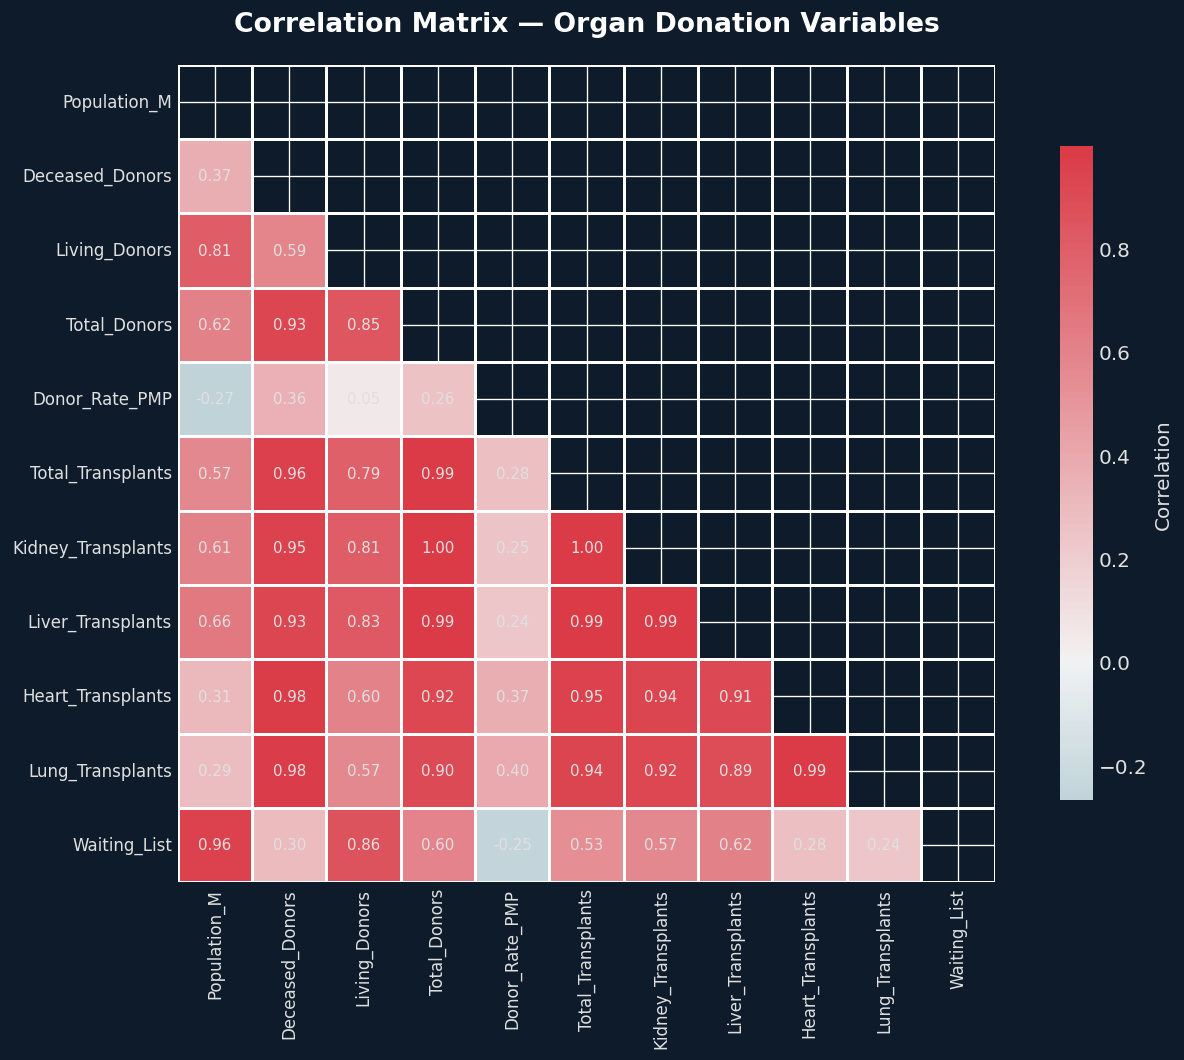

In [15]:
# Correlation heatmap with seaborn (dark theme)
numeric_cols = ['Population_M', 'Deceased_Donors', 'Living_Donors', 'Total_Donors',
                'Donor_Rate_PMP', 'Total_Transplants', 'Kidney_Transplants',
                'Liver_Transplants', 'Heart_Transplants', 'Lung_Transplants', 'Waiting_List']

corr = df_country[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9), facecolor='#0d1b2a')
ax.set_facecolor('#0d1b2a')
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, center=0, annot=True, fmt='.2f',
            square=True, linewidths=0.8, cbar_kws={"shrink": 0.8, "label": "Correlation"},
            annot_kws={"size": 9, "color": "#e0e0e0"})
ax.set_title('Correlation Matrix — Organ Donation Variables', fontsize=16, fontweight='bold', pad=20, color='#ffffff')
ax.tick_params(colors='#e0e0e0', labelsize=10)
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(color='#e0e0e0')
cbar.ax.yaxis.label.set_color('#e0e0e0')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#e0e0e0')
plt.tight_layout()
plt.show()